<a href="https://colab.research.google.com/github/kolden0/KNURE/blob/main/LB3_kolden.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Класифікація зображеннь з використанням mnist dataset
## 1.1 Мета роботи
* Зрозуміте, як глибоке навчання може вирішувати проблеми, які не можуть вирішити традиційні методи програмування
* Розібратися в [MNIST handwritten digits dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)
* Створити просту нейронну мережу для класифікації зображень
* Навчить нейронну мережу, використовуючи підготовлений набір даних MNIST
* Проаналізувати ефективність та кількісні показники роботи навченої нейронної мережі

Імпортуємо необхідні бібліотеки. Якщо, вони ще не були встановлені, використайте команду pip install для встановлення бібліотек

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

# Visualization tools
import torchvision
import torchvision.transforms.v2 as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

### 1.1.1 Задача: Класифікація зображеннь

У традиційному програмуванні програміст може формулювати правила та умови у коді, які програма може потім використовувати для правильної поведінки.

Класифікація зображень вимагає від програми правильно класифікувати зображення, яке вона ніколи раніше не бачила. Таку задачу практично неможливо вирішити традиційними методами програмування. Як програміст може визначити правила та умови для правильної класифікації величезної кількості зображень, особливо враховуючи зображення, які він ніколи раніше не бачив?

### 1.1.2 Рішення: Глибоке навчання
Глибоке навчання чудово розпізнає образи методом спроб і помилок. Навчаючи глибоку нейронну мережу достатньою кількістю даних та надаючи мережі зворотний зв'язок щодо її продуктивності через навчання, мережа може визначити власний набір умов, за яких вона може діяти правильно.

## 1.2 Набір даних MNIST
 MNIST датасек - колекція з 70 000 зображень у градаціях сірого рукописних цифр від 0 до 9. Хоча сьогодні ця проблема вважається тривіальною, класифікація зображень за допомогою MNIST стала своєрідним «Hellow World» для глибокого навчання.

### 1.2.1 Training та Validation данні та мітки
Під час роботи із зображеннями для глибокого навчання нам потрібні як самі зображення, зазвичай позначені як X, так і правильні мітки для цих зображень, зазвичай позначені як Y. Крім того, нам потрібні значення X та Y як для навчання моделі, так і окремий набір значень X та Y для перевірки продуктивності моделі після її навчання.

Ми можемо уявити ці пари X та Y як набір карток. Студент може навчатися з одним набором карток, а щоб перевірити, чи засвоїв студент правильні поняття, вчитель може провести тестування з іншим набором карток.

Тому нам потрібні 4 сегменти даних для набору даних MNIST:

x_train: Зображення, що використовуються для навчання нейронної мережі
y_train: Правильні мітки для зображень x_train, що використовуються для оцінки прогнозів моделі під час навчання
x_valid: Зображення, відкладені для перевірки продуктивності моделі після її навчання
y_valid: Правильні мітки для зображень x_valid, що використовуються для оцінки прогнозів моделі після її навчання

### 1.2.2 Завантаження даних за допомогою TorchVision
Існує багато фреймворків для глибокого навчання, кожен з яких має свої переваги. В рамках цієї роботи ми працюватимемо з фрейморком PyTorch, а саме з Sequential API. Sequential API має багато корисних вбудованих функцій, призначених для побудови нейронних мереж. Він також є гарним вибором для глибокого навчання в професійному середовищі завдяки своїй читабельності та ефективності.

Також використаємо бібліотеку TorchVision. Однією з багатьох корисних функцій, які вона надає, є модулі, що містять допоміжні методи для багатьох поширених наборів даних, включаючи MNIST.

Почнемо із завантаження датасетів для навчання та валідіції MNIST. Попередньо завантажте датасети [MNIST handwritten digits dataset](https://www.kaggle.com/datasets/hojjatk/mnist-dataset) та ропакуйте їх у папку mnist там де запускаэться цей ноутбук

In [ ]:
train_set = torchvision.datasets.MNIST("./mnist/", train=True, download=True)
valid_set = torchvision.datasets.MNIST("./mnist/", train=False, download=True)

100.0%
100.0%
100.0%
100.0%


Подивіться інформацію про датасет

In [ ]:
train_set

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./mnist/
    Split: Train

In [ ]:
valid_set

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./mnist/
    Split: Test

### 1.2.3 Дослідження датасету
Подивіться на дані та відповідні мітки

In [ ]:
x_0, y_0 = train_set[0]

In [ ]:
x_0

In [ ]:
type(x_0)

PIL.Image.Image

Це цифра 5 або погано написана цифра 3?

In [ ]:
y_0

5

In [ ]:
type(y_0)

int

## 1.3 Тензори
Якщо вектор є одновимірним масивом, а матриця — двовимірним масивом, то тензор — це n-вимірний масив, що представляє будь-яку кількість вимірів. Більшість сучасних нейронних мережевих фреймворків є потужними інструментами для обробки тензорів.

Одним із прикладів тривимірного тензора можуть бути пікселі на екрані комп'ютера. Різними вимірами будуть ширина, висота та колірний. Відеоігри використовують матричну математику для обчислення значень пікселів подібно до того, як нейронні мережі обчислюють тензори. Ось чому графічні процесори є ефективними машинами для обробки тензорів.

Давайте перетворимо наші зображення на тензори, щоб пізніше ми могли обробити їх за допомогою нейронної мережі. TorchVision має корисну функцію для перетворення обєкти зображень PIL на тензори за допомогою класу ToTensor:

In [ ]:
trans = transforms.Compose([transforms.ToTensor()])
x_0_tensor = trans(x_0)

D:\dev\python\new\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
x_0_tensor.dtype

torch.float32

Ми можемо перевірити мінімальне та максимальне значення. Зображення PIL мають потенційний цілочисельний діапазон [0, 255], але клас ToTensor перетворює його на діапазон чисел з плаваючою комою [0.0, 1.0].

In [ ]:
x_0_tensor.min()

tensor(0.)

In [ ]:
x_0_tensor.max()

tensor(1.)

Ми також можемо переглянути розмір кожного виміру. PyTorch використовує домовленість C x H x W, що означає, що перший вимір – це колірний канал, другий – висота, а третій – ширина.

Оскільки ці зображення чорно-білі, є лише 1 колірний канал. Зображення квадратні, мають 28 пікселів у висоту та ширину:

In [ ]:
x_0_tensor.size()

torch.Size([1, 28, 28])

In [ ]:
x_0_tensor

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

In [ ]:
x_0_tensor.device

device(type='cpu')

Іноді буває важко інтерпретувати таку велику кількість чисел. На щастя, TorchVision може конвертувати тензори C x H x W назад у зображення PIL за допомогою функції to_pil_image.

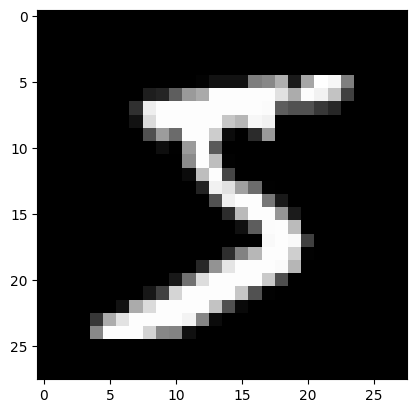

In [ ]:
image = F.to_pil_image(x_0_tensor)
plt.imshow(image, cmap='gray')

## 1.4 Підготовка даних для навчання
Раніше ми створили змінну trans для перетворення зображення в тензор. Трансформації – це група функцій torchvision, які можна використовувати для перетворення набору даних.

### 1.4.1 Transforms
Функція Compose використовується для об'єднання списку перетворень

In [ ]:
trans = transforms.Compose([transforms.ToTensor()])

In [ ]:
train_set.transform = trans
valid_set.transform = trans

### 1.4.2 DataLoaders
Якщо наш набір даних – це колода карт, завантажувач даних (DataLoader) визначає, як ми витягуємо карти з колоди для навчання моделі. Ми могли б показати нашим моделям весь набір даних одночасно. Це не тільки вимагає багато обчислювальних ресурсів, але й дослідження показують, що використання меншого пакету даних є ефективнішим для навчання моделі.

Наприклад, якщо наш batch_size дорівнює 32, ми навчатимемо нашу модель, перетасовуючи колоду та витягуючи 32 карти. Нам не потрібно перетасовувати для перевірки, оскільки модель не навчається, але ми все одно використовуватимемо batch_size, щоб запобігти помилкам пам'яті.

Розмір пакету вирішує розробник моделі, і найкраще значення залежатиме від проблеми, яку потрібно вирішити. Дослідження показують, що 32 або 64 достатньо для багатьох задач машинного навчання та є значенням за замовчуванням у деяких фреймворках машинного навчання, тому тут ми використовуватимемо 32.

In [ ]:
batch_size = 32

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size)

## 1.5 Створення моделі
Нейронні мережі складаються з шарів, де кожен шар виконує математичну операцію над отриманими даними, перш ніж передати їх наступному шару. Для початку ми створимо модель, що складається з 4 компонентів:
* Згладжування (Flatten), яке використовується для перетворення n-вимірних даних у вектор.
* Вхідний шар, перший шар нейронів.
* Прихований шар, ще один шар нейронів, "захований" між входом і виходом.
* Вихідний шар, останній набір нейронів, який повертає остаточне передбачення з моделі.

Змінна(лист) layers буде зберігати інформацію про шари.

In [ ]:
layers = []
layers

[]

### 1.5.1 Згладжування (Flattening) зодраження
Коли ми розглянули форму наших даних вище, ми побачили, що зображення мають 3 виміри: C x H x W. Згладити зображення означає об'єднати всі ці зображення в 1 вимір. Припустимо, у нас є тензор, як показано нижче. Спробуйте запустити комірку коду, щоб побачити, як він виглядає до і після згладжування.

In [ ]:
test_matrix = torch.tensor(
    [[1, 2, 3],
     [4, 5, 6],
     [7, 8, 9]]
)
test_matrix

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

In [ ]:
nn.Flatten()(test_matrix)

tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

Нічого не сталося? Це тому, що нейронні мережі очікують отримання пакету даних. Наразі шар Flatten бачить три вектори, а не одну двовимірну матрицю. Щоб виправити це, ми можемо "пакетувати" наші дані, додавши додаткову пару дужок. Оскільки test_matrix тепер є тензором, ми можемо зробити це за допомогою скорочення нижче. None додає новий вимір, де : вибирає всі дані в тензорі.

In [ ]:
batch_test_matrix = test_matrix[None, :]
batch_test_matrix

tensor([[[1, 2, 3],
         [4, 5, 6],
         [7, 8, 9]]])

In [ ]:
nn.Flatten()(batch_test_matrix)

tensor([[1, 2, 3, 4, 5, 6, 7, 8, 9]])

Додамо `Flatten` шар до списку шарів у листі `layers`.

In [ ]:
layers = [
    nn.Flatten()
]
layers

[Flatten(start_dim=1, end_dim=-1)]

### 1.5.2 Вхідний шар
Наш перший шар нейронів з'єднує наше вирівняне зображення з рештою нашої моделі. Для цього ми використовуватимемо лінійний шар. Цей шар буде щільно зв'язаним, тобто кожен нейрон у ньому та його ваги впливатимуть на кожен нейрон у наступному шарі.

Щоб створити ці ваги, PyTorch повинен знати розмір наших вхідних даних та кількість нейронів, які ми хочемо створити. Оскільки ми вирівняли наші зображення, розмір наших вхідних даних – це кількість каналів, кількість пікселів по вертикалі та кількість пікселів по горизонталі, помножені разом.

In [ ]:
input_size = 1 * 28 * 28

Вибір правильної кількості нейронів – це окрема задача у «науці про дані», оскільки це питання фіксації статистичної складності набору даних. Наразі ми використовуватимемо 512 нейронів. Поекспериментувати з цим значенням, щоб побачити, як воно впливає на процес навчання.

Використуємо функцію активації relu, яка допоможе нашій мережі навчитися робити складніші припущення щодо даних.

In [ ]:
layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU()]

### 1.5.3 Прихований шар
Тепер ми додамо додатковий щільнозв'язаний лінійний шар. Так само, як вхідний шар мав знати форму даних, що йому передавалися, nn.Linear прихованого шару повинен знати форму даних, що йому передавалися. Кожен нейрон у попередньому шарі обчислюватиме одне число, тому кількість вхідних даних у прихований шар буде такою ж, як і кількість нейронів у попередньому.

In [ ]:
layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
    nn.Linear(512, 512),  # Hidden
    nn.ReLU()  # Activation for hidden
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=512, bias=True),
 ReLU()]

### 1.5.4 Вихідний шар
Нарешті, ми додамо вихідний шар. У цьому випадку, оскільки мережа має зробити припущення щодо приналежності одного зображення до 1 з 10 можливих категорій, буде 10 виходів. Кожному виходу призначається нейрон. Чим більше значення вихідного нейрона порівняно з іншими нейронами, тим більше модель передбачає, що вхідне зображення належить до класу, призначеного вихідному нейрону.

Ми не будемо призначати функцію relu вихідному шару. Натомість ми застосуємо функцію втрат, яка розглядається в наступному розділі.

In [ ]:
n_classes = 10

layers = [
    nn.Flatten(),
    nn.Linear(input_size, 512),  # Input
    nn.ReLU(),  # Activation for input
    nn.Linear(512, 512),  # Hidden
    nn.ReLU(),  # Activation for hidden
    nn.Linear(512, n_classes)  # Output
]
layers

[Flatten(start_dim=1, end_dim=-1),
 Linear(in_features=784, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=512, bias=True),
 ReLU(),
 Linear(in_features=512, out_features=10, bias=True)]

### 1.5.5 Компіляція моделі
Послідовна модель очікує послідовність аргументів, а не список, тому ми можемо використовувати оператор * для розпакування нашого списку шарів у послідовність. Ми можемо вивести модель, щоб перевірити правильність завантаження цих шарів.

In [ ]:
model = nn.Sequential(*layers)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)

У PyTorch 2.0 було запроваджено можливість компілювати модель для швидшої роботи.

In [ ]:
#model = torch.compile(model)
model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)

## 1.6 Training the Model
Так само, як вчителі оцінюють учнів, нам потрібно надати моделі функцію, за допомогою якої можна оцінювати її відповіді. Це називається функцією втрат. Ми використовуватимемо тип функції втрат під назвою CrossEntropy, яка призначена для оцінювання, якщо модель передбачила правильну категорію з групи категорій.

In [ ]:
loss_function = nn.CrossEntropyLoss()

Далі ми вибираємо оптимізатор для нашої моделі. Якщо функція втрат (loss_function) надає оцінку, оптимізатор повідомляє моделі, як навчитися на цій оцінці, щоб наступного разу працювати краще.

In [ ]:
optimizer = Adam(model.parameters())

### 1.6.2 Розрахунок точності
Хоча результати функції втрат ефективно допомагають нашій моделі навчатися, ці значення можуть бути важкими для інтерпретації людьми. Саме тому фахівці з обробки даних часто включають інші показники, такі як точність (Accuracy).

Щоб точно розрахувати точність, нам слід порівняти кількість правильних класифікацій із загальною кількістю зроблених прогнозів. Оскільки ми показуємо дані моделі пакетами, нашу точність можна розрахувати разом з цими пакетами.

По-перше, загальна кількість прогнозів має такий самий розмір, як і наш набір даних. Давайте призначимо розмір наших наборів даних N, де n є синонімом розміру пакета.

In [ ]:
train_N = len(train_loader.dataset)
valid_N = len(valid_loader.dataset)

Далі ми створимо функцію для обчислення точності для кожної пакету (batch). Результатом буде частка від загальної точності, тож ми можемо додати точність кожного пакету, щоб отримати загальну суму.

In [ ]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

### 1.6.3 Функція навчання
Нижче наведено функцію, яку ми визначили для навчання нашої моделі на основі навчальних даних.

In [ ]:
def train():
    loss = 0
    accuracy = 0

    model.train()
    for x, y in train_loader:
        #x, y = x.to(device), y.to(device)
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
        accuracy += get_batch_accuracy(output, y, train_N)
    print('Train - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

### 1.6.4 Функція перевірки
Аналогічно, це код для перевірки моделі з даними, на яких вона не навчалася. Чи можете ви помітити якісь відмінності з функцією `train`?

In [ ]:
def validate():
    loss = 0
    accuracy = 0

    model.eval()
    with torch.no_grad():
        for x, y in valid_loader:
            #x, y = x.to(device), y.to(device)
            output = model(x)

            loss += loss_function(output, y).item()
            accuracy += get_batch_accuracy(output, y, valid_N)
    print('Valid - Loss: {:.4f} Accuracy: {:.4f}'.format(loss, accuracy))

### 1.6.5 Цикл навчання моделі
Щоб побачити, як проходить процес навчання моделі, ми будемо чергувати навчання та перевірку. Так само, як студенту може знадобитися кілька разів переглянути свою колоду карток, щоб вивчити всі концепції, модель пройде навчальні дані кілька разів, щоб отримати краще розуміння.

In [ ]:
epochs = 5

for epoch in range(epochs):
    print('Epoch: {}'.format(epoch))
    train()
    validate()

Epoch: 0
Train - Loss: 380.4704 Accuracy: 0.9397
Valid - Loss: 39.8250 Accuracy: 0.9594
Epoch: 1
Train - Loss: 159.4904 Accuracy: 0.9735
Valid - Loss: 22.9587 Accuracy: 0.9765
Epoch: 2
Train - Loss: 109.4919 Accuracy: 0.9817
Valid - Loss: 21.7281 Accuracy: 0.9802
Epoch: 3
Train - Loss: 81.5264 Accuracy: 0.9860
Valid - Loss: 34.0093 Accuracy: 0.9688
Epoch: 4
Train - Loss: 67.6779 Accuracy: 0.9882
Valid - Loss: 29.8837 Accuracy: 0.9771


Перевірка разультатів роботи нашої моделі

In [ ]:
prediction = model(x_0_tensor)
prediction


tensor([[-28.8493, -11.2874, -16.2585,   9.3433, -33.5061,  16.8877, -26.0175,
         -13.7983, -13.1199, -10.1158]], grad_fn=<AddmmBackward0>)

In [ ]:
x_0